## <center> **Customer Satisfication Probability Prediction** </center>
----

### Import libraries

In [1]:
import pandas as pd
from matplotlib import pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import pickle

### Load and Preview dataset

In [2]:
df = pd.read_csv("customer_satisfication_dataset.csv")
df.head(3)

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,97251,91922,Female,Loyal Customer,28,Business travel,Business,2586,5,5,...,4,5,2,5,4,4,4,0,0.0,satisfied
1,73321,40958,Female,Loyal Customer,42,Business travel,Business,507,3,3,...,4,4,4,4,4,4,3,0,0.0,satisfied
2,52533,1251,Male,Loyal Customer,28,Personal Travel,Eco,113,3,1,...,2,3,2,2,1,2,2,12,12.0,neutral or dissatisfied


### Shape of the data

In [3]:
df.shape

(51952, 25)

### Total columns

In [4]:
total_columns = 0
for column in df.columns:
    print(f"- {column}")
    total_columns += 1

print(f"\nTotal columns: {total_columns}")

- Unnamed: 0
- id
- Gender
- Customer Type
- Age
- Type of Travel
- Class
- Flight Distance
- Inflight wifi service
- Departure/Arrival time convenient
- Ease of Online booking
- Gate location
- Food and drink
- Online boarding
- Seat comfort
- Inflight entertainment
- On-board service
- Leg room service
- Baggage handling
- Checkin service
- Inflight service
- Cleanliness
- Departure Delay in Minutes
- Arrival Delay in Minutes
- satisfaction

Total columns: 25


### Categorical columns

In [5]:
categorical_cols = df.select_dtypes(include=["object"])
total = 0
for column in categorical_cols:
    print(f"- {column}")
    total += 1
print(f"\nCategorical columns: {total}")

- Gender
- Customer Type
- Type of Travel
- Class
- satisfaction

Categorical columns: 5


### Numeric columns

In [6]:
numeric_cols = df.select_dtypes(include=["number"])
total = 0
for column in numeric_cols:
    print(f"- {column}")
    total += 1

print(f"\nNumeric columns: {total}")

- Unnamed: 0
- id
- Age
- Flight Distance
- Inflight wifi service
- Departure/Arrival time convenient
- Ease of Online booking
- Gate location
- Food and drink
- Online boarding
- Seat comfort
- Inflight entertainment
- On-board service
- Leg room service
- Baggage handling
- Checkin service
- Inflight service
- Cleanliness
- Departure Delay in Minutes
- Arrival Delay in Minutes

Numeric columns: 20


### Basic information

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51952 entries, 0 to 51951
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         51952 non-null  int64  
 1   id                                 51952 non-null  int64  
 2   Gender                             51952 non-null  object 
 3   Customer Type                      51952 non-null  object 
 4   Age                                51952 non-null  int64  
 5   Type of Travel                     51952 non-null  object 
 6   Class                              51952 non-null  object 
 7   Flight Distance                    51952 non-null  int64  
 8   Inflight wifi service              51952 non-null  int64  
 9   Departure/Arrival time convenient  51952 non-null  int64  
 10  Ease of Online booking             51952 non-null  int64  
 11  Gate location                      51952 non-null  int

### Statistical Summary of the Numeric Columns

In [8]:
df.describe()

,Unnamed: 0,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,51952.000000,51952.000000,51952.000000,51952.000000,51952.000000,51952.000000,51952.000000,51952.000000,51952.000000,51952.000000,51952.000000,51952.000000,51952.000000,51952.000000,51952.000000,51952.000000,51952.000000,51952.000000,51952.000000,51791.000000
mean,51914.814848,65000.096146,39.312577,1190.288786,2.720665,3.057341,2.749962,2.974207,3.197875,3.245034,3.434132,3.352017,3.380871,3.350747,3.631737,3.301817,3.642728,3.283415,14.826205,15.153868
std,30077.699366,37464.886490,15.113837,998.322850,1.323967,1.526310,1.393703,1.272844,1.327361,1.349743,1.319965,1.333109,1.290306,1.317849,1.183761,1.268557,1.174171,1.310587,38.369271,38.793338
min,0.000000,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25632.750000,32565.500000,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,51998.500000,64949.500000,40.000000,843.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,78044.500000,97469.500000,51.000000,1744.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,103902.000000,129878.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


### Missing values

In [9]:
df.isnull().sum()

Unnamed: 0                             0
id                                     0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             161
satisfaction    

- Only Arrival Delay in Minutes column contains missing values

### Percentage of Missing Values in `Arrival Delay in Minutes` column

In [13]:
df["Arrival Delay in Minutes"].isnull().sum() / round(len(df) * 100)

3.0990144748999075e-05

### Duplicate values

In [12]:
df.duplicated().sum()

np.int64(0)

- No duplicate values

### Total number of Satisfied and Dissatisfied Customer

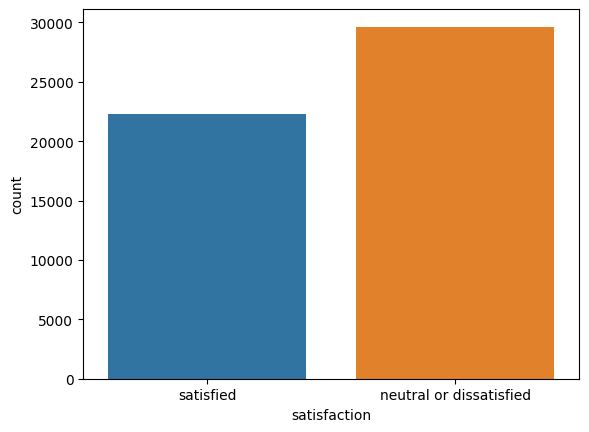

In [14]:
sns.countplot(
    x= df["satisfaction"]
)

plt.show()

### Percentage of Satisfied Customers

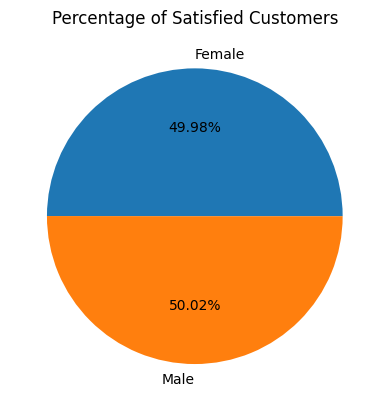

In [15]:
satisfied = df[df["satisfaction"] == "satisfied"].groupby("Gender")["satisfaction"].count()

plt.pie(
    x= satisfied.values,
    labels= satisfied.index,
    autopct="%.2f%%"
)

plt.title("Percentage of Satisfied Customers")
plt.show()

### Percentage of Dissatisfied customers

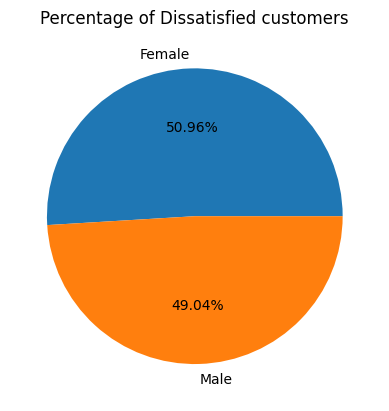

In [16]:
dissatisfied = df[df["satisfaction"] == "neutral or dissatisfied"].groupby("Gender")["satisfaction"].count()

plt.pie(
    x= dissatisfied.values,
    labels= dissatisfied.index,
    autopct="%.2f%%"
)

plt.title("Percentage of Dissatisfied customers")
plt.show()

### Satisfied Customers by Gender

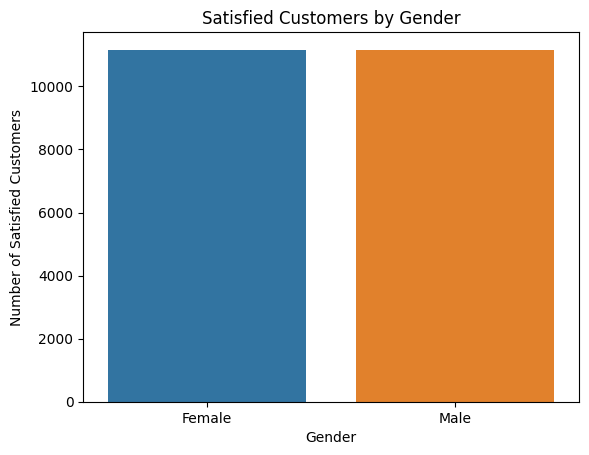

In [18]:
satisfied = df[df["satisfaction"] == "satisfied"].groupby("Gender")["satisfaction"].count()

sns.barplot(
    x= satisfied.index,
    y= satisfied.values
)


plt.title("Satisfied Customers by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Satisfied Customers")
plt.show()

### Dissafisfied Customers by Gender

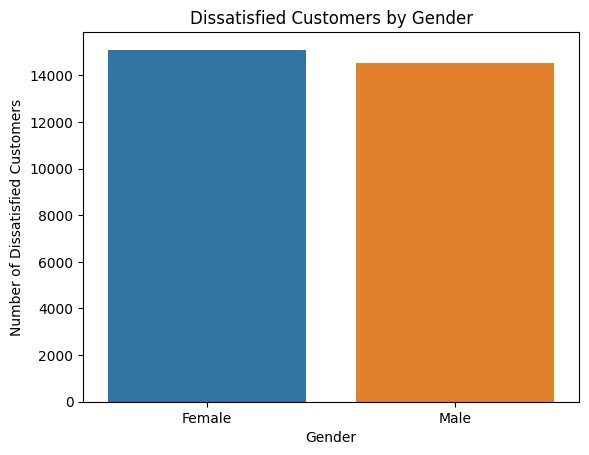

In [19]:
dissatisfied = df[df["satisfaction"] == "neutral or dissatisfied"].groupby("Gender")["satisfaction"].count()

sns.barplot(
    x= dissatisfied.index,
    y= dissatisfied.values
)

plt.title("Dissatisfied Customers by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Dissatisfied Customers")
plt.show()

### Satisfied Customers by Class

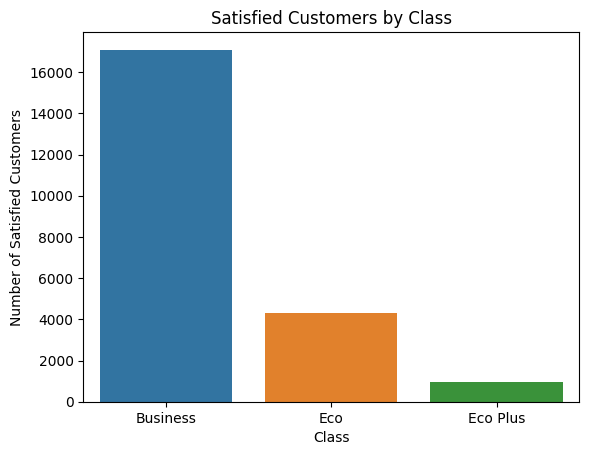

In [20]:
satisfied = df[df["satisfaction"] == "satisfied"].groupby("Class")["satisfaction"].count()

sns.barplot(
    x= satisfied.index,
    y= satisfied.values
)

plt.title("Satisfied Customers by Class")
plt.xlabel("Class")
plt.ylabel("Number of Satisfied Customers")
plt.show()

### Numer of Dissatisfied Customers by Class

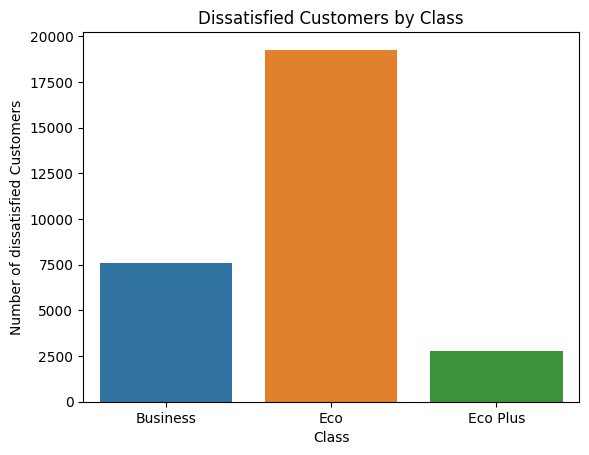

In [21]:
dissatisfied = df[df["satisfaction"] == "neutral or dissatisfied"].groupby("Class")["satisfaction"].count()

sns.barplot(
    x= dissatisfied.index,
    y= dissatisfied.values
)

plt.title("Dissatisfied Customers by Class")
plt.xlabel("Class")
plt.ylabel("Number of dissatisfied Customers")
plt.show()

### Satisfied Customers by Type of Travel

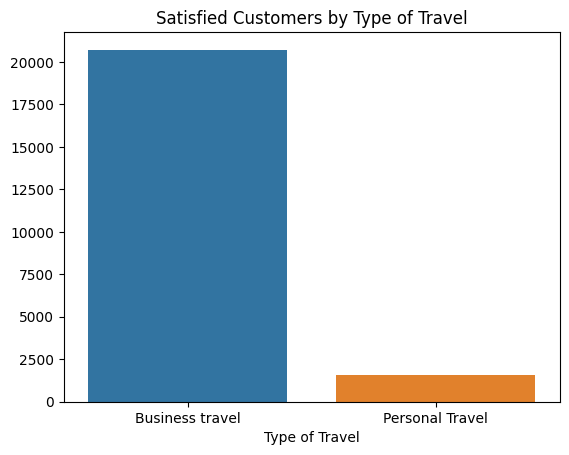

In [22]:
satisfied = df[df["satisfaction"] == "satisfied"].groupby("Type of Travel")["satisfaction"].count()

sns.barplot(
    x= satisfied.index,
    y= satisfied.values
)
plt.title("Satisfied Customers by Type of Travel")
plt.show()

### Dissatisfied Customers by Type of Travel

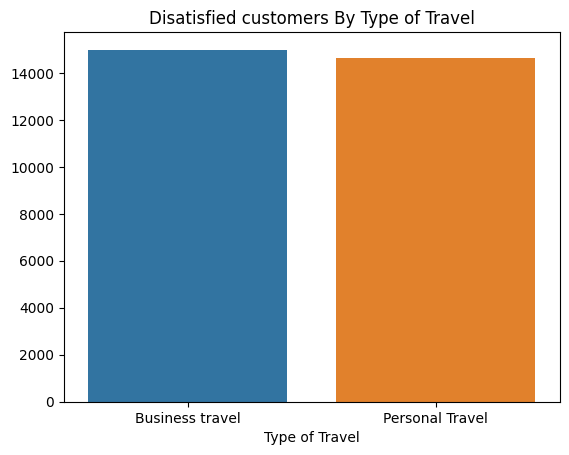

In [23]:
dissatisfied = df[df["satisfaction"] == "neutral or dissatisfied"].groupby("Type of Travel")["satisfaction"].count()

sns.barplot(
    x= dissatisfied.index,
    y= dissatisfied.values
)

plt.title("Disatisfied customers By Type of Travel")
plt.show()

### Correlation Matrix

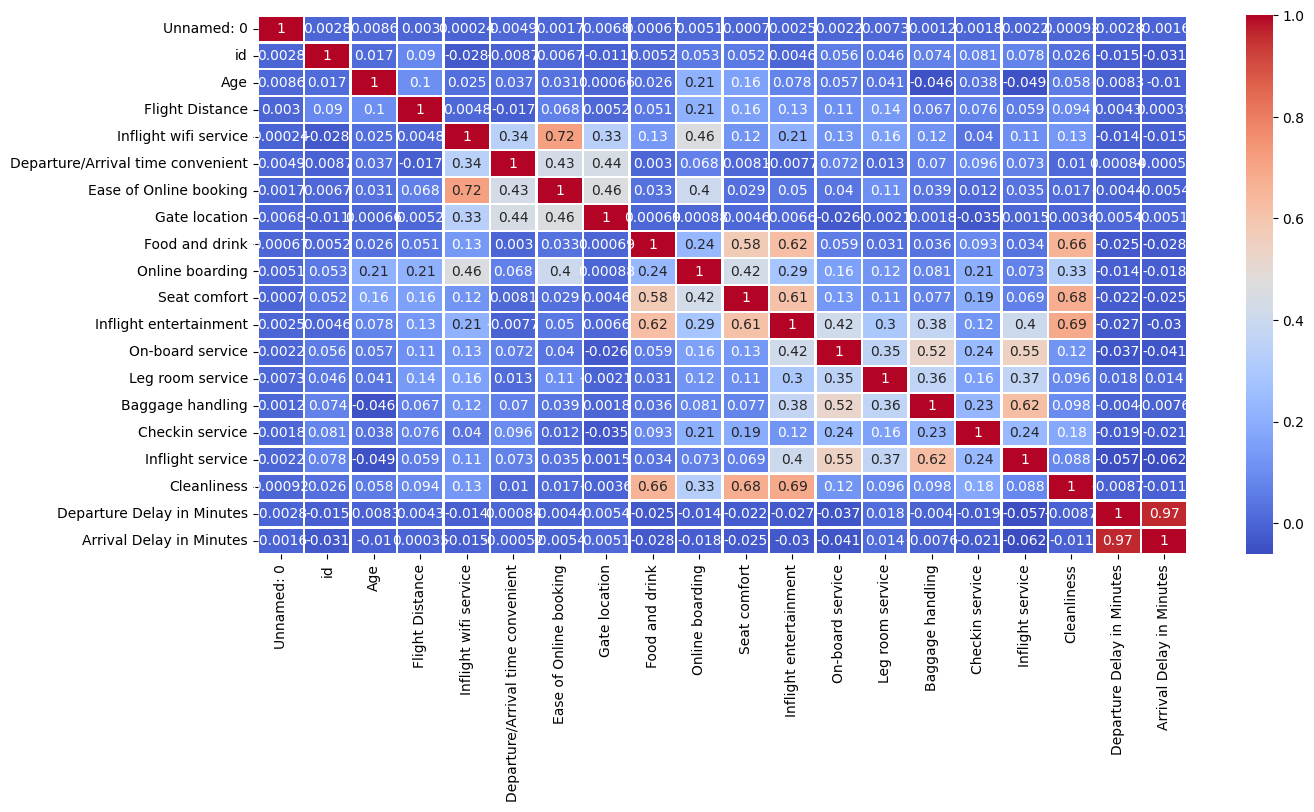

In [24]:
corr= numeric_cols.corr()

plt.figure(figsize=(15, 7))
sns.heatmap(
    corr,
    annot=True,
    cmap= "coolwarm",
    linecolor="White",
    linewidths= 1
)

plt.show()

### Drop irrelavent columns

In [25]:
df.drop(columns=["Unnamed: 0", "id"], axis= 1, inplace= True)

### Fill missing values

In [26]:
df["Arrival Delay in Minutes"] = df["Arrival Delay in Minutes"].fillna(df["Arrival Delay in Minutes"].median())

### Convert Categorical into Numerics

In [27]:
df["Gender"] = df["Gender"].map({
    "Male": 1,
    "Female": 0
})

df["Customer Type"] = df["Customer Type"].map({
    'Loyal Customer': 1,
    'disloyal Customer': 0
})

df["Type of Travel"] = df["Type of Travel"].map({
    'Business travel': 1,
    'Personal Travel': 0
})

df["Class"] = df["Class"].map({
    'Business': 1,
    'Eco': 2,
    'Eco Plus': 3
})

df["satisfaction"] = df["satisfaction"].map({
    'satisfied': 1,
    'neutral or dissatisfied': 0
})


### Features and Target

In [28]:
X = df.drop("satisfaction", axis=1)
y = df["satisfaction"]

### Training and Test Sets

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Initialize and Train Model

In [29]:
model = RandomForestClassifier(n_estimators=350, min_samples_split=11)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",350
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",11
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metri

### Make Predictions

In [30]:
y_pred = model.predict(X_test)
print(y_pred)

[0 1 1 ... 1 0 0]


### Evaluate Model

In [31]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.98      0.96      5915
           1       0.97      0.94      0.95      4476

    accuracy                           0.96     10391
   macro avg       0.96      0.96      0.96     10391
weighted avg       0.96      0.96      0.96     10391



### Confusion Matrix

In [32]:
print(confusion_matrix(y_test, y_pred))

[[5784  131]
 [ 290 4186]]


### Save Model

In [33]:
with open("model.pkl", "wb") as file:
    pickle.dump(model, file)